### LightGBM Regression Model – Complete Machine Learning Pipeline

#### Overview
This notebook demonstrates how to build a complete machine learning pipeline using **LightGBM's LGBMRegressor** for a regression problem.

We will cover the full workflow used in professional machine learning projects:

- Data loading
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Feature engineering
- Machine learning pipeline
- Model training
- Hyperparameter tuning
- Model evaluation
- Model explainability using SHAP
- Model saving



#### What is LightGBM?

LightGBM (Light Gradient Boosting Machine) is a **gradient boosting framework developed by Microsoft** designed for high performance and efficiency.

It uses **decision tree algorithms** and is optimized for:

- Faster training speed
- Lower memory usage
- Higher accuracy
- Better performance on large datasets



#### Type of Problem

This notebook demonstrates a **Regression Problem**.

Regression models predict **continuous numeric values**, such as:

Examples:

- House price prediction
- Sales forecasting
- Energy consumption prediction
- Stock price estimation
- Demand forecasting


#### Why LightGBM?

Advantages:

- Extremely fast
- Handles large datasets efficiently
- Works well with high dimensional data
- Supports parallel and GPU learning
- Often wins machine learning competitions

**Importing Libraries**

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn tools
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Dataset
from sklearn.datasets import fetch_california_housing

# Model
from lightgbm import LGBMRegressor

# Model interpretation
import shap

# Feature importance
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# Save model
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

**Load dataset**

In [2]:
from sklearn.datasets import fetch_california_housing

# Load dataset
data = fetch_california_housing(as_frame=True)

In [3]:
df = data.frame

In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (20640, 9)


In [5]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
# Dataset description
print(data.DESCR[:1500])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

**Exploratory Data Analysis (EDA)**

In [7]:
# Data types
df.dtypes

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

In [8]:
# Missing values
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [9]:
# Statistical summary
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


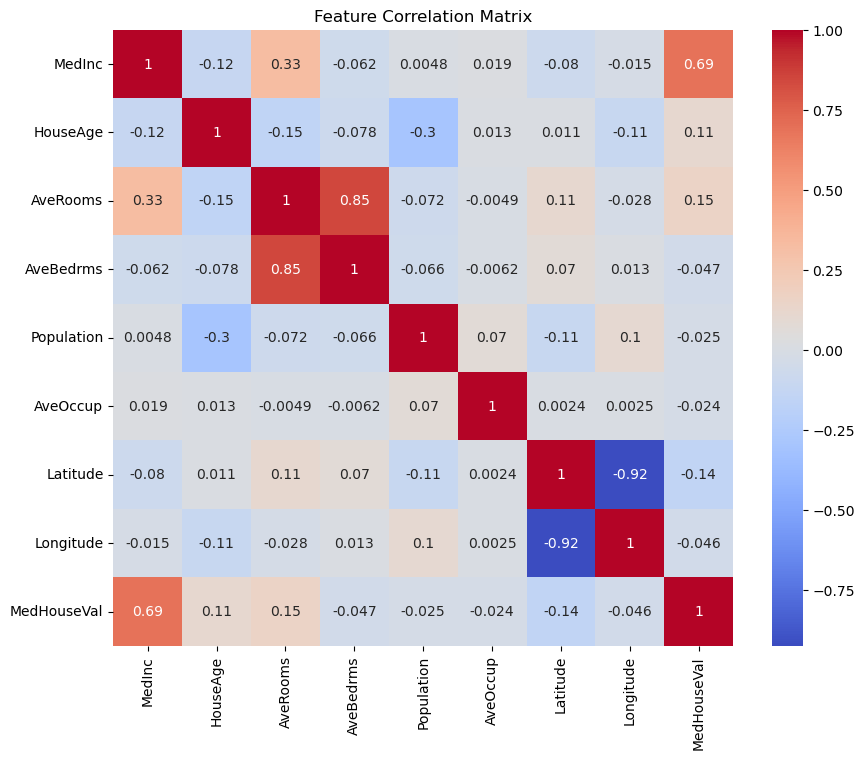

In [10]:
# Correlation Matrix
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

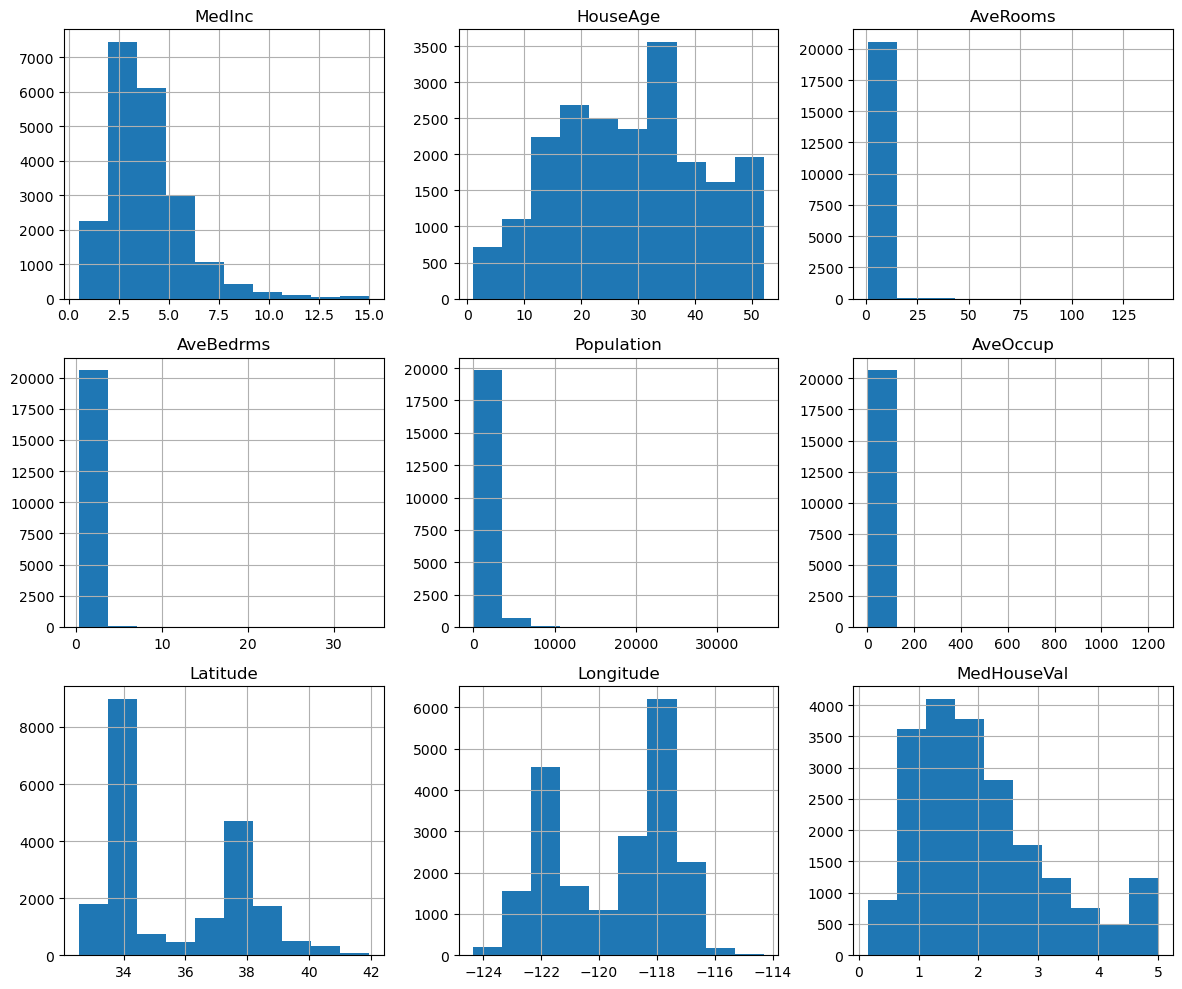

In [11]:
# Distribution Plots
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

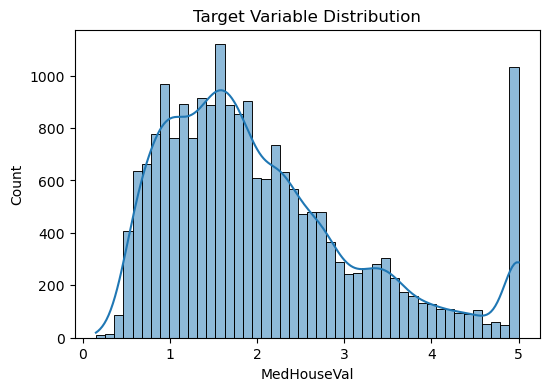

In [12]:
# Target Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['MedHouseVal'], kde=True)
plt.title("Target Variable Distribution")
plt.show()

**Data Preprocessing**

In [13]:
# Separate features and target
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

In [14]:
# Identify numerical features
num_features = X.columns.tolist()

In [15]:
# Preprocessing Pipeline
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features)
    ]
)

**Feature Engineering**

In [16]:
# Example feature engineering
df["Rooms_per_Household"] = df["AveRooms"] / df["HouseAge"]
df["Population_per_Household"] = df["Population"] / df["AveOccup"]

In [17]:
# Update features
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

**Train-Test Split**

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (16512, 10)
Test shape: (4128, 10)


**Machine Learning Pipeline**

In [20]:
model = LGBMRegressor(random_state=42)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

**Model Training**

In [21]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

In [22]:
pipeline.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000450 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.071947


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['MedInc', 'HouseAge',
                                                   'AveRooms', 'AveBedrms',
                                                   'Population', 'AveOccup',
                                                   'Latitude',
                                                   'Longitude'])])),
                ('model', LGBMRegressor(random_state=42))])

**Hyperparameter Tuning with GridSearchCV**

In [23]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [-1, 5, 10],
    "model__num_leaves": [31, 50, 100]
}


In [24]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

In [25]:
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000961 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.071947
Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': -1, 'model__n_estimators': 300, 'model__num_leaves': 50}
Best CV Score: 0.8442205558755875


**Model Evaluation**

In [26]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

In [27]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [28]:
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 0.437217260489902
MAE: 0.28482763666040767
R2 Score: 0.8541226929573486


**Residual Plot**

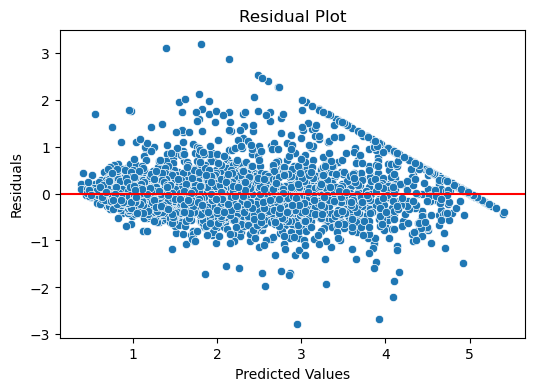

In [29]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red')
plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

**Feature Importance Visualization**

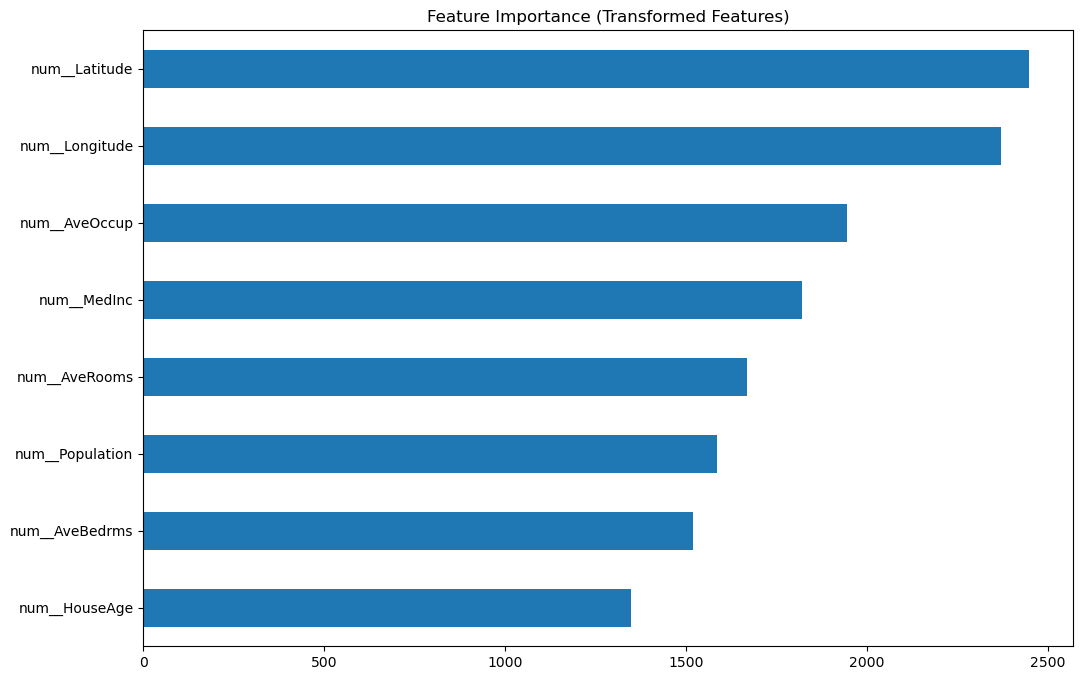

In [30]:
preprocessor = best_model.named_steps["preprocessor"]
model = best_model.named_steps["model"]

# Get transformed feature names
features = preprocessor.get_feature_names_out()  # scikit-learn >=1.0
importance = model.feature_importances_

# Create Series
feat_imp = pd.Series(importance, index=features)
feat_imp.sort_values().plot(kind="barh", figsize=(12,8))
plt.title("Feature Importance (Transformed Features)")
plt.show()

**Learning Curve**

In [31]:
from sklearn.model_selection import learning_curve

In [32]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000172 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1416
[LightGBM] [Info] Number of data points in the train set: 1651, number of used features: 8
[LightGBM] [Info] Start training from score 2.447820
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000320 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1581
[LightGBM] [Info] Number of data points in the train set: 5366, number of used features: 8
[LightGBM] [Info] Start training from score 2.358832
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000512 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1832
[LightGBM] [Info] Number of data points in the train set: 9081, number of used features: 8
[LightGBM] [Info] Start training 

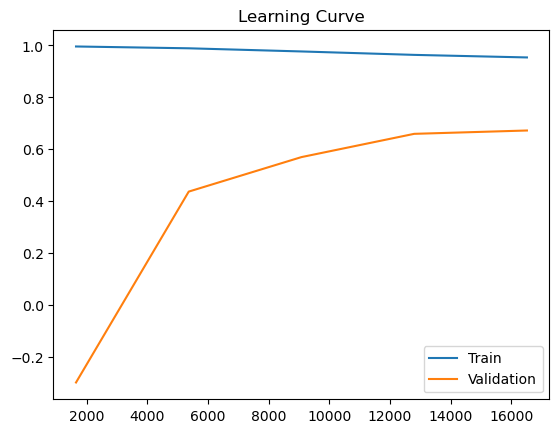

In [33]:
plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Validation")
plt.legend()
plt.title("Learning Curve")
plt.show()

**Model Explainability**

In [35]:
# Use the pipeline's preprocessor
preprocessor = pipeline.named_steps["preprocessor"]

# Transform X_test
X_test_transformed = preprocessor.transform(X_test)

# Check shape
print(X_test_transformed.shape)  # Should match model input (n_samples, 8)

(4128, 8)


In [36]:
perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

perm_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm_importance.importances_mean
}).sort_values(by="Importance", ascending=False)

perm_df

,Feature,Importance
6,Latitude,0.991048
7,Longitude,0.865442
0,MedInc,0.344059
5,AveOccup,0.152885
2,AveRooms,0.094000
1,HouseAge,0.045499
3,AveBedrms,0.008773
4,Population,0.008677
8,Rooms_per_Household,0.000000
9,Population_per_Household,0.000000


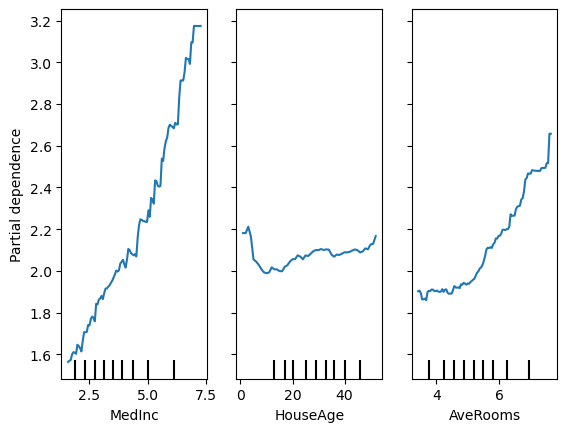

In [37]:
PartialDependenceDisplay.from_estimator(
    best_model,
    X_test,
    features=[0,1,2]
)
plt.show()

## Key Insights

1. The most important features influencing house price are:
   - Median Income
   - Average Rooms
   - Latitude / Longitude

2. LightGBM performs well because:
   - It captures non-linear relationships
   - Handles feature interactions automatically

3. The model shows good generalization because:
   - Train and validation scores are close
   - Residuals are evenly distributed

Possible Improvements:

- Feature engineering
- More hyperparameter tuning
- Ensemble models

In [38]:
joblib.dump(best_model, "lightgbm_regression_model.pkl")

print("Model saved successfully!")

Model saved successfully!


### Model Theory: XGBoost

#### 1. Algorithm Overview

XGBoost is based on **Gradient Boosting**, where models are built sequentially.

Each new tree learns from the **errors of previous trees**.

Final prediction:

$$
\hat{y} = \sum_{k=1}^{K} f_k(x)
$$

where:

* (f_k) is a decision tree
* (K) is number of trees


#### 2. Mathematical Intuition

XGBoost minimizes:

$$
Loss + Regularization
$$

$$
L = \sum l(y_i, \hat{y}_i) + \sum \Omega(f_k)
$$

Regularization prevents overfitting.



#### 3. When to Use XGBoost

Use when:

* Dataset is **structured/tabular**
* Non-linear relationships exist
* High predictive accuracy is required
* Medium to large datasets


#### 4. Advantages

* Very high accuracy
* Handles missing values
* Built-in regularization
* Fast training
* Feature importance


#### 5. Disadvantages

* Many hyperparameters
* Can overfit small datasets
* Not ideal for images/text (deep learning better)
